In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller,acf,pacf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

print("All imports successful")

All imports successful


In [5]:
df= yf.download("SPY", start="2018-01-01",
                end="2024-01-01", auto_adjust=True)
df.columns =df.columns.get_level_values(0)
price = df["Close"]
log_returns = np.log(price / price.shift(1)).dropna()

print(f"Price observations : {len(price)}")
print(f"Return observations : {len(log_returns)}")
print(f"Date range : {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Price observations : 1509
Return observations : 1508
Date range : 2018-01-02 to 2023-12-29


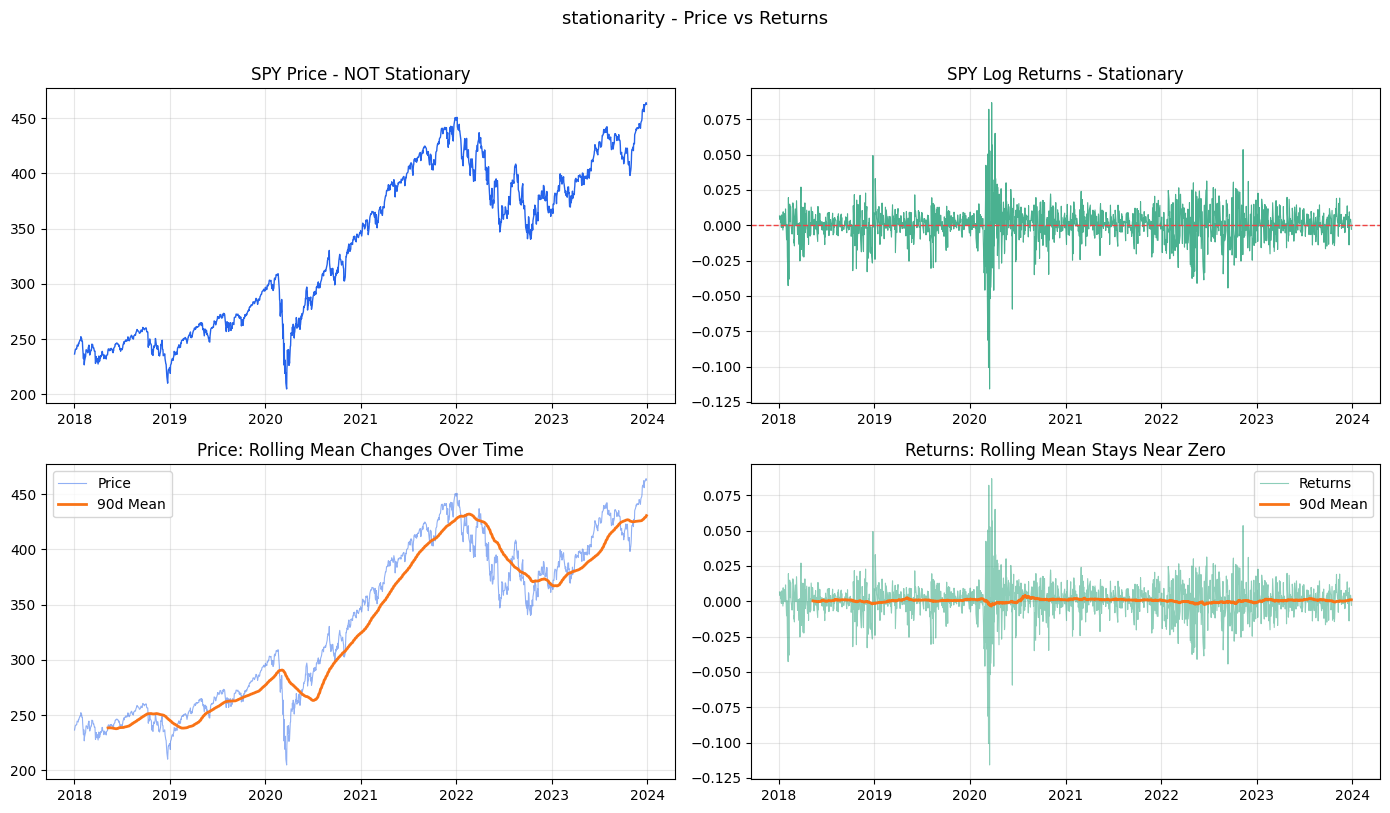

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

#Raw price
axes[0,0].plot(price, color='#2563eb', lw=1)
axes[0,0].set_title('SPY Price - NOT Stationary')
axes[0,0].grid(True, alpha=0.3)

#Log returns
axes[0,1].plot(log_returns, color='#1D9E75', lw=0.8, alpha=0.8)
axes[0,1].axhline(0, color='#ef4444', lw=1, linestyle='--')
axes[0,1].set_title('SPY Log Returns - Stationary')
axes[0,1].grid(True, alpha=0.3)

#Rolling mean of price
rolling_mean_price=price.rolling(90).mean()
axes[1,0].plot(price, color='#2563eb', lw=0.8, alpha=0.5, label='Price')
axes[1,0].plot(rolling_mean_price, color='#f97316', lw=2, label='90d Mean')
axes[1,0].set_title('Price: Rolling Mean Changes Over Time')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

#Rolling mean of returns
rolling_mean_ret =log_returns.rolling(90).mean()
axes[1,1].plot(log_returns, color='#1D9E75', lw=0.8, alpha=0.5, label='Returns')
axes[1,1].plot(rolling_mean_ret, color='#f97316', lw=2, label='90d Mean')
axes[1,1].set_title('Returns: Rolling Mean Stays Near Zero')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('stationarity - Price vs Returns', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
def adf_test(series, name):
    """
    Run Augmented Dickey-Fuller stationarity test.
    H0: series has a unit root (non-stationary)
    If p<0.05: reject H0, series IS stationary
    """
    result = adfuller(series.dropna())

    print(f"\n{name} - ADF Test")
    print(f"{'='*40}")
    print(f" ADF Statistic : {result[0]:>10.4f}")
    print(f" p-value : {result[1]:>10.6f}")
    print(f" Critical 1% : {result[4]['1%']:>10.4f}")
    print(f" Critical 5% : {result[4]['5%']:>10.4f}")
    print(f"{'='*40}")
    print(f" Result: {'STATIONARY' if result[1]<0.05 else 'NON-STATIONARY'}")

#Test both price and returns
adf_test(price, "SPY Price")
adf_test(log_returns, "SPY Log Returns")


SPY Price - ADF Test
 ADF Statistic :    -0.6843
 p-value :   0.850776
 Critical 1% :    -3.4347
 Critical 5% :    -2.8635
 Result: NON-STATIONARY

SPY Log Returns - ADF Test
 ADF Statistic :   -11.8791
 p-value :   0.000000
 Critical 1% :    -3.4347
 Critical 5% :    -2.8635
 Result: STATIONARY


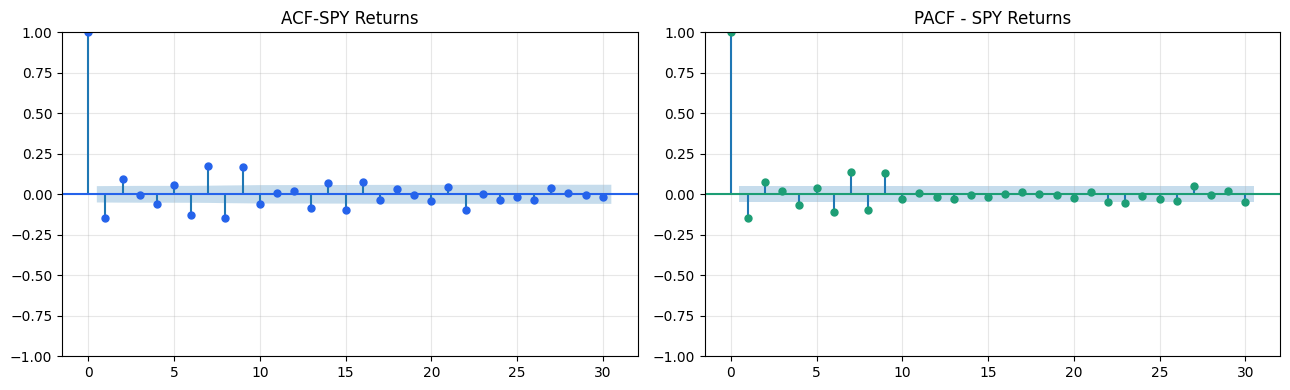

In [13]:
fig, axes=plt.subplots(1, 2, figsize=(13, 4))

plot_acf(log_returns, lags=30, ax=axes[0],
         color='#2563eb', title='ACF-SPY Returns')
axes[0].grid(True, alpha=0.3)

plot_pacf(log_returns, lags=30, ax=axes[1],
          color='#1D9E75', title='PACF - SPY Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

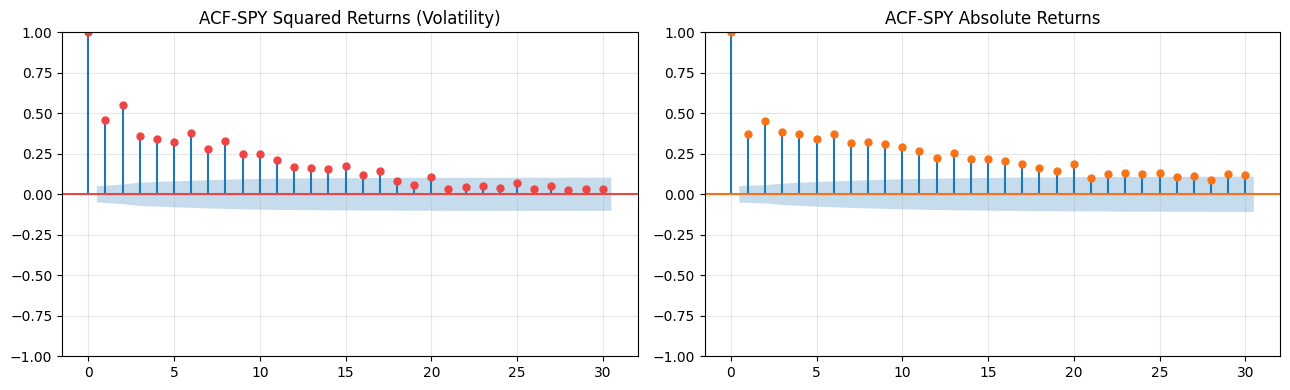

In [14]:
fig, axes = plt.subplots(1,2, figsize=(13, 4))

plot_acf(log_returns**2, lags=30, ax=axes[0],
         color='#ef4444', title='ACF-SPY Squared Returns (Volatility)')
axes[0].grid(True, alpha=0.3)

plot_acf(np.abs(log_returns), lags=30, ax=axes[1],
         color='#f97316', title='ACF-SPY Absolute Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

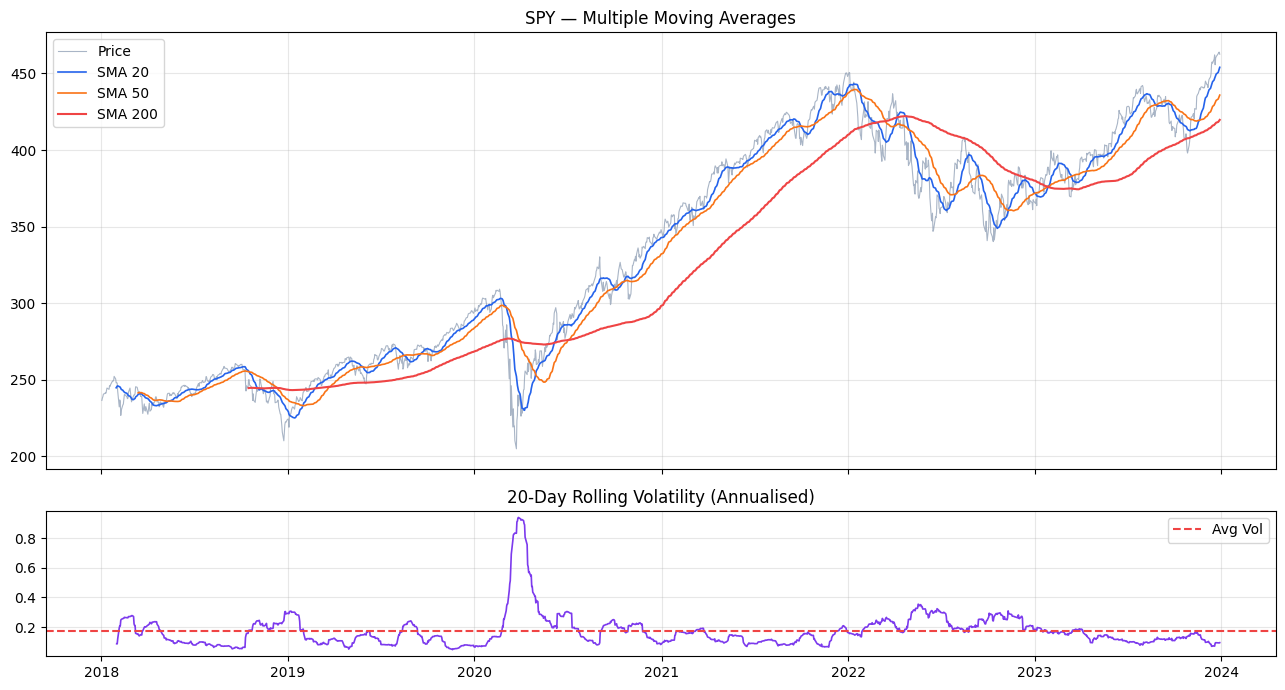

In [15]:
# Rolling statistics — the workhorse of technical strategies
sma_20  = price.rolling(window=20).mean()
sma_50  = price.rolling(window=50).mean()
sma_200 = price.rolling(window=200).mean()
roll_std = log_returns.rolling(window=20).std() * np.sqrt(252)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(price,   color='#94a3b8', lw=0.8,  alpha=0.8, label='Price')
ax1.plot(sma_20,  color='#2563eb', lw=1.2,  label='SMA 20')
ax1.plot(sma_50,  color='#f97316', lw=1.2,  label='SMA 50')
ax1.plot(sma_200, color='#ef4444', lw=1.5,  label='SMA 200')
ax1.set_title('SPY — Multiple Moving Averages')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(roll_std, color='#7c3aed', lw=1.2)
ax2.axhline(roll_std.mean(), color='#ef4444',
            lw=1.5, linestyle='--', label='Avg Vol')
ax2.set_title('20-Day Rolling Volatility (Annualised)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed



  SPY TIME SERIES ANALYSIS
  Price stationary?   : NO (p=0.8508)
  Returns stationary? : YES (p=0.0000)
  Significant ACF lags: [1, 2, 4, 5, 6, 7, 8, 9, 10]
  Vol clustering lags : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


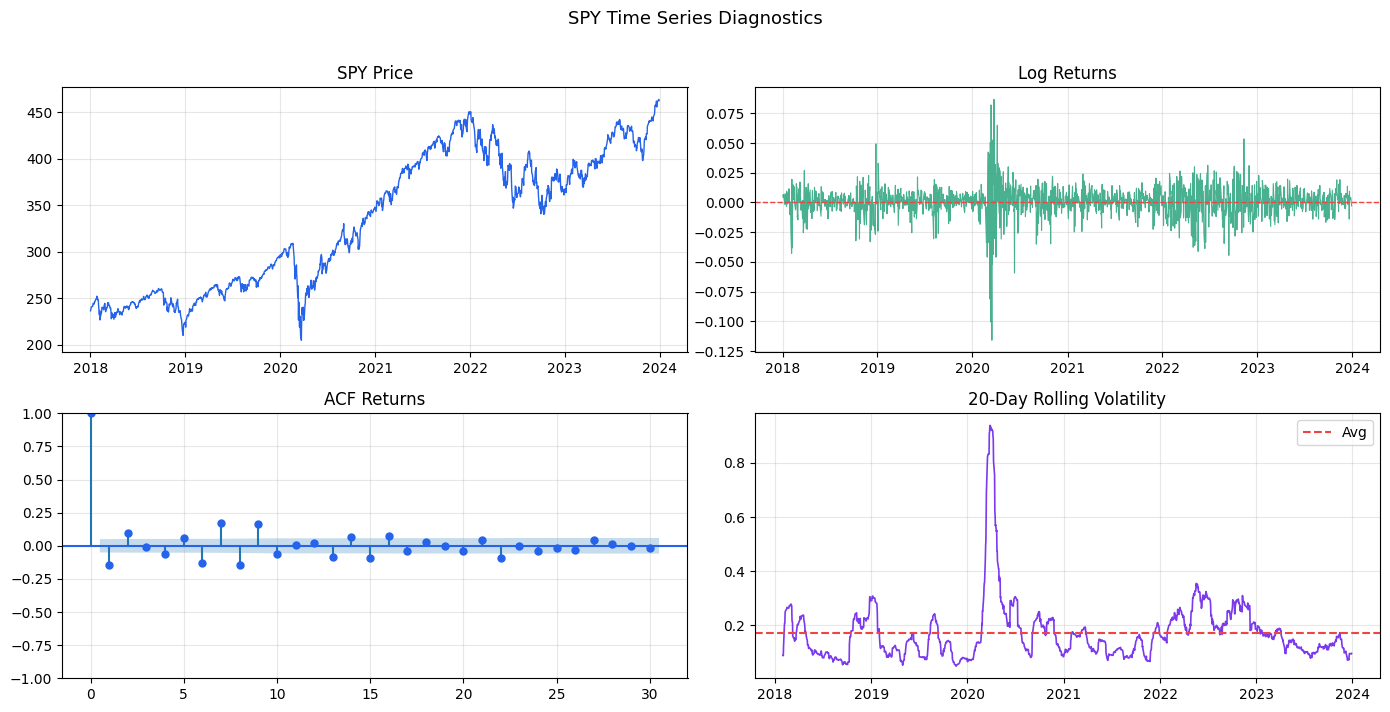

[*********************100%***********************]  1 of 1 completed



  AAPL TIME SERIES ANALYSIS
  Price stationary?   : NO (p=0.8897)
  Returns stationary? : YES (p=0.0000)
  Significant ACF lags: [1, 7, 8, 9]
  Vol clustering lags : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


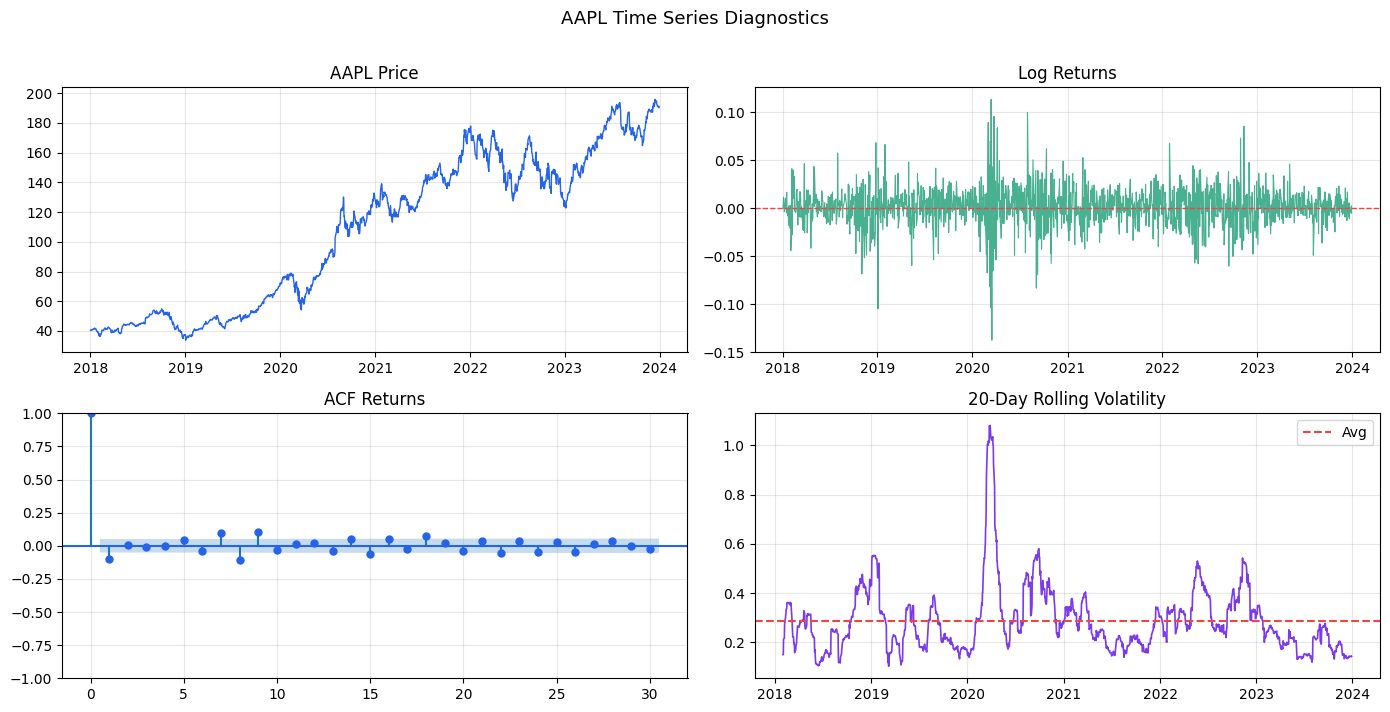

[*********************100%***********************]  1 of 1 completed



  BTC-USD TIME SERIES ANALYSIS
  Price stationary?   : NO (p=0.6330)
  Returns stationary? : YES (p=0.0000)
  Significant ACF lags: [1, 2]
  Vol clustering lags : [1, 4, 7]


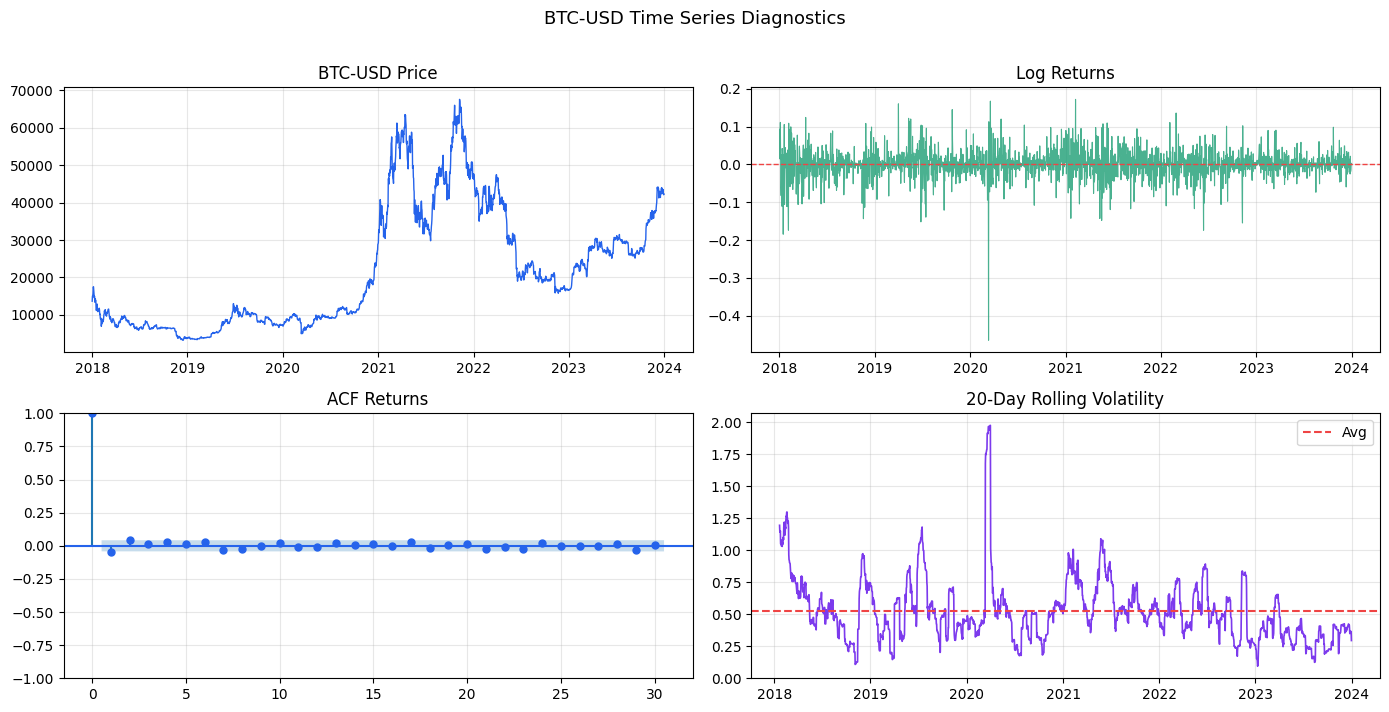

In [16]:
def timeseries_analysis(ticker, start="2018-01-01", end="2024-01-01"):
    """
    Full time series diagnostic for any ticker.
    Tests stationarity, autocorrelation, and rolling stats.
    """
    # --- Data ---
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    price = df["Close"]
    returns = np.log(price / price.shift(1)).dropna()

    # --- ADF Tests ---
    adf_price   = adfuller(price)
    adf_returns = adfuller(returns)

    print(f"\n{'='*45}")
    print(f"  {ticker} TIME SERIES ANALYSIS")
    print(f"{'='*45}")
    print(f"  Price stationary?   : {'YES' if adf_price[1]   < 0.05 else 'NO'} (p={adf_price[1]:.4f})")
    print(f"  Returns stationary? : {'YES' if adf_returns[1] < 0.05 else 'NO'} (p={adf_returns[1]:.4f})")

    # --- Autocorrelation summary ---
    acf_vals = acf(returns, nlags=10, fft=True)
    sig_lags = [i for i, v in enumerate(acf_vals[1:], 1)
                if abs(v) > 2/np.sqrt(len(returns))]
    print(f"  Significant ACF lags: {sig_lags if sig_lags else 'None — no autocorrelation'}")

    # --- Volatility clustering ---
    acf_sq = acf(returns**2, nlags=10, fft=True)
    sig_sq = [i for i, v in enumerate(acf_sq[1:], 1)
              if abs(v) > 2/np.sqrt(len(returns))]
    print(f"  Vol clustering lags : {sig_sq if sig_sq else 'None'}")
    print(f"{'='*45}")

    # --- 4-panel chart ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))

    # Price
    axes[0,0].plot(price, color='#2563eb', lw=1)
    axes[0,0].set_title(f'{ticker} Price')
    axes[0,0].grid(True, alpha=0.3)

    # Returns
    axes[0,1].plot(returns, color='#1D9E75', lw=0.8, alpha=0.8)
    axes[0,1].axhline(0, color='#ef4444', lw=1, linestyle='--')
    axes[0,1].set_title('Log Returns')
    axes[0,1].grid(True, alpha=0.3)

    # ACF of returns
    plot_acf(returns, lags=30, ax=axes[1,0],
             color='#2563eb', title='ACF Returns')
    axes[1,0].grid(True, alpha=0.3)

    # Rolling volatility
    roll_vol = returns.rolling(20).std() * np.sqrt(252)
    axes[1,1].plot(roll_vol, color='#7c3aed', lw=1.2)
    axes[1,1].axhline(roll_vol.mean(), color='#ef4444',
                      lw=1.5, linestyle='--', label='Avg')
    axes[1,1].set_title('20-Day Rolling Volatility')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.suptitle(f'{ticker} Time Series Diagnostics', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Test on 3 assets
timeseries_analysis("SPY")
timeseries_analysis("AAPL")
timeseries_analysis("BTC-USD")